Copyright 2018 The TensorFlow Datasets Authors, Licensed under the Apache License, Version 2.0

In [192]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_datasets as tfds

In [193]:
# mnist = tf.keras.datasets.mnist

# (x_train, y_train), (x_test, y_test) = mnist.load_data()

Exporting EMNIST Database

In [194]:
# Load the EMNIST "byclass" split
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/byclass',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Define the preprocessing function to correct the image orientation and normalize
def preprocess(image, label):
    # Cast to float32 and normalize to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # The EMNIST images in TFDS are rotated, so we need to fix it
    image = tf.image.rot90(image)
    image = tf.image.flip_up_down(image)
    # image = tf.image.flip_left_right(image)
    return image, label

# Apply the preprocessing function to the datasets
ds_train = ds_train.map(preprocess)
ds_test = ds_test.map(preprocess)

x_train, y_train = [], []
x_test, y_test   = [], []

for img, label in tfds.as_numpy(ds_train):
    x_train.append(img)
    y_train.append(label)

for img, label in tfds.as_numpy(ds_test):
    x_test.append(img)
    y_test.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test  = np.array(x_test)
y_test  = np.array(y_test)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

2025-09-06 21:54:15.795312: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(697932, 28, 28, 1) (697932,)
(116323, 28, 28, 1) (116323,)


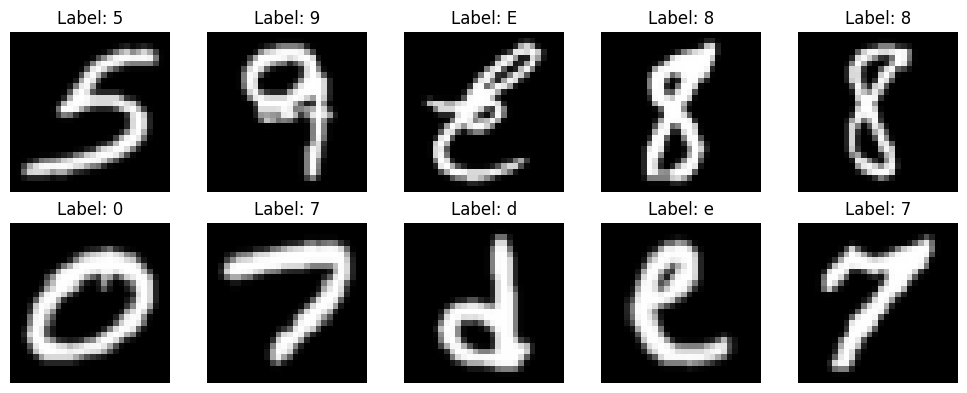

In [195]:
import string

# Create a list for the 62 possible characters
mapping = list(string.digits) + list(string.ascii_uppercase) + list(string.ascii_lowercase)

def get_char_from_label(label):
    """
    Converts an integer label from the emnist/byclass dataset to its character.
    """
    if 0 <= label <= 61:
        return mapping[label]
    else:
        return "Invalid Label"

# Take a larger, shuffled sample and visualize them in a grid
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i, (image, label) in enumerate(ds_train.take(10)):
    # Convert the TensorFlow tensor to a NumPy array for plotting
    image_np = image.numpy().squeeze()

    # Get the character from the integer label
    label_char = get_char_from_label(label.numpy())

    # Plot the image and title
    axes[i].imshow(image_np, cmap='gray')
    axes[i].set_title(f"Label: {label_char}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [196]:
rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows,cols,1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = np.array(y_train).reshape(-1)  # shape (N,)
y_test = np.array(y_test).reshape(-1)    # shape (N,)

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 62)
y_test = tf.keras.utils.to_categorical(y_test, 62)

LeNet Model Build

In [197]:
def build_lenet(input_shape):
    model = tf.keras.Sequential()

    # C1 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=6, kernel_size=(5,5), activation='tanh', input_shape=input_shape))
    # S2 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C3 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(5,5), activation='tanh'))  # usually 16 filters, not 6
    # S4 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # Flatten
    model.add(tf.keras.layers.Flatten())

    # C5 Fully Connected Layer
    model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

    # FC6 Fully Connected Layers
    model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

    # Output Layer
    model.add(tf.keras.layers.Dense(units=62, activation='softmax'))

    return model

lenet = build_lenet(input_shape)

/Users/chvicencio/Desktop/Projects/FreehandToText/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [226]:
# Compile the model
lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We will be allowing 10 itterations to happen
epochs = 15
batch_size = 128//2
history = lenet.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

# Check Accuracy of the Model
# Transform labels to one hot encoding


Epoch 1/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.8431 - loss: 0.4396
Epoch 2/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.8447 - loss: 0.4346
Epoch 3/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 55s 5ms/step - accuracy: 0.8459 - loss: 0.4294
Epoch 4/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.8471 - loss: 0.4253
Epoch 5/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.8480 - loss: 0.4208
Epoch 6/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.8491 - loss: 0.4176
Epoch 7/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.8501 - loss: 0.4147
Epoch 8/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.8509 - loss: 0.4116
Epoch 9/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - accuracy: 0.8515 - loss: 0.4093
Epoch 10/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.8523 - loss: 0.4065
Epoch 11/15
10906/10906 ━━━━━━━━━━━━━━━━━━━━ 55s 5ms/step - accuracy: 0.8528 - loss: 0.40

In [227]:
loss ,acc= lenet.evaluate(x_test, y_test)

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8482 - loss: 0.4281


Accuracy :  0.8482243418693542
Training Data (697932, 28, 28) (697932, 62)
Test Data (116323, 28, 28) (116323, 62)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Result prediction :: S


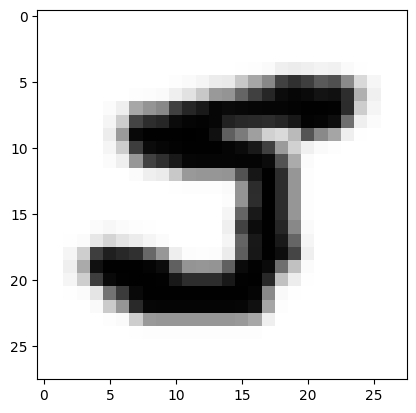

In [265]:

print('Accuracy : ', acc)

x_train = x_train.reshape(x_train.shape[0], 28,28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28,28)
print('Test Data', x_test.shape, y_test.shape)

# Plot the Image
image_index = np.random.randint(0, x_test.shape[0])
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')

# Make Prediction
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1 ))
print(f"Result prediction :: {get_char_from_label(pred.argmax())}")

Accuracy :  0.8482243418693542
Training Data (697932, 28, 28) (697932, 62)
Test Data (116323, 28, 28) (116323, 62)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Result prediction :: C


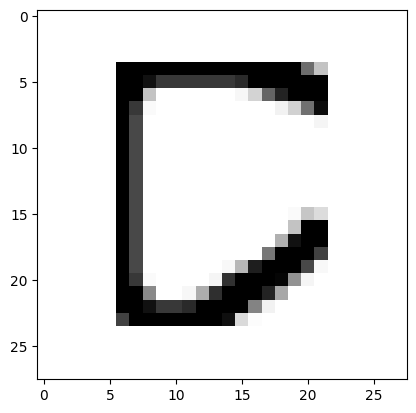

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Result prediction :: h


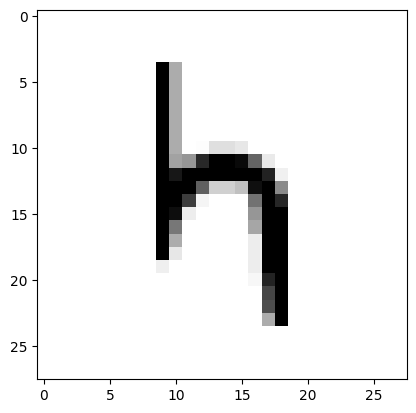

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Result prediction :: N


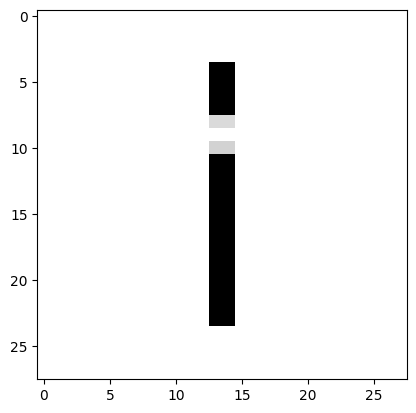

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Result prediction :: r


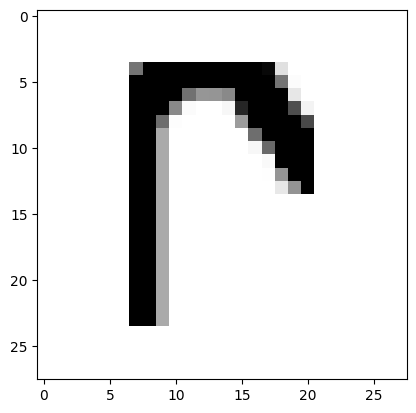

In [295]:
import os
from PIL import Image

image_dir = "Drawings"

print('Accuracy : ', acc)

x_train = x_train.reshape(x_train.shape[0], 28,28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28,28)
print('Test Data', x_test.shape, y_test.shape)

try:
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]

    for image_file in image_files:
        img_path = os.path.join(image_dir, image_file)
        img = Image.open(img_path).convert('L')  # Convert to grayscale

        img_np = 1.0 - (np.array(img) / 255.0)

        # Make Prediction
        pred = lenet.predict(img_np.reshape(1, rows, cols, 1 ))
        print(f"Result prediction :: {get_char_from_label(pred.argmax())}")

        # Display
        plt.imshow(img_np.reshape(28,28), cmap='Greys')
        plt.show()

except Exception as e:
    if e == FileNotFoundError:
        print("File not found")

    print(f"Error: {e}")
